Using customer retail dataset implement various models and compare them.
Project Objective

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# Load Dataset

df = pd.read_csv("customer_retail.csv")

print(df.head())

# Handle Missing Values

df.dropna(inplace=True)

# Encode Country Column

le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

# Create Target Variable

df['Target'] = np.where(
    df['Quantity'] > df['Quantity'].median(),
    1,
    0
)

print(df.head())

   Quantity  UnitPrice    Country
0        39      52.36  Australia
1        29      70.60  Australia
2        15      37.00    Germany
3        43      97.21     France
4         8      96.28    Germany
   Quantity  UnitPrice  Country  Target
0        39      52.36        0       1
1        29      70.60        0       1
2        15      37.00        2       0
3        43      97.21        1       1
4         8      96.28        2       0


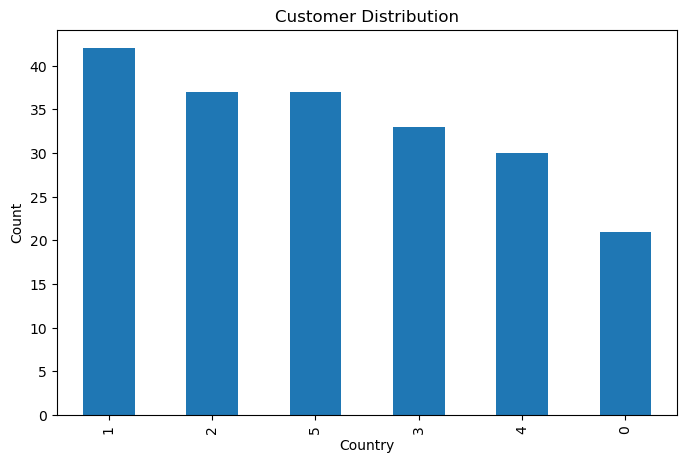

In [4]:
# Customer Distribution Graph

plt.figure(figsize=(8,5))

df['Country'].value_counts().plot(kind='bar')

plt.title("Customer Distribution")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

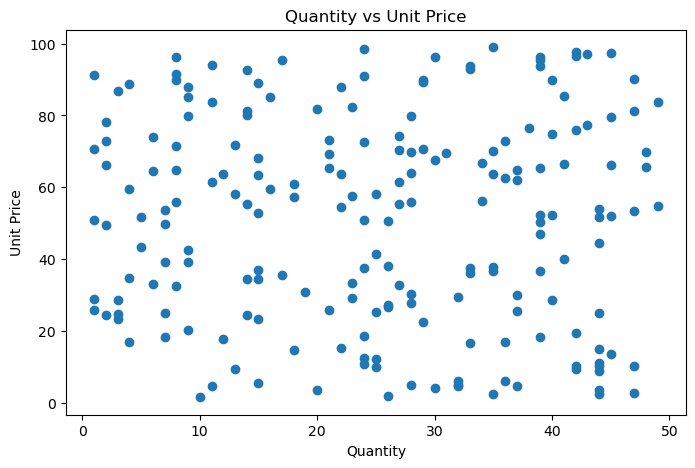

In [5]:
# Quantity vs Unit Price

plt.figure(figsize=(8,5))

plt.scatter(df['Quantity'], df['UnitPrice'])

plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")

plt.show()

In [6]:
# Feature Selection

X = df[['Quantity','UnitPrice','Country']]
y = df['Target']

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

# Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

# KNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [7]:
# Accuracy Scores

acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)
acc_knn = accuracy_score(y_test, pred_knn)

print("Logistic Regression Accuracy =", acc_lr)
print("Decision Tree Accuracy =", acc_dt)
print("KNN Accuracy =", acc_knn)

Logistic Regression Accuracy = 1.0
Decision Tree Accuracy = 1.0
KNN Accuracy = 0.975


In [8]:
# Confusion Matrices

print("\nLogistic Regression")
print(confusion_matrix(y_test, pred_lr))

print("\nDecision Tree")
print(confusion_matrix(y_test, pred_dt))

print("\nKNN")
print(confusion_matrix(y_test, pred_knn))


Logistic Regression
[[19  0]
 [ 0 21]]

Decision Tree
[[19  0]
 [ 0 21]]

KNN
[[18  1]
 [ 0 21]]


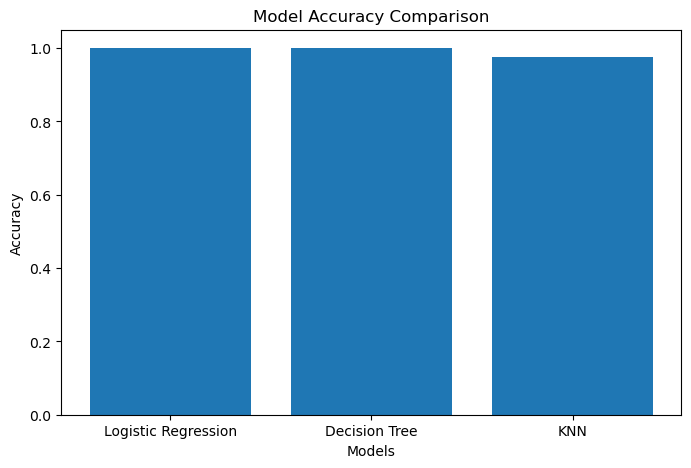

In [9]:
# Accuracy Comparison Graph

models = ['Logistic Regression',
          'Decision Tree',
          'KNN']

accuracy = [acc_lr,
            acc_dt,
            acc_knn]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

The customer retail dataset was successfully analyzed using Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN) algorithms. Data preprocessing techniques such as handling missing values and label encoding were applied before model training. The models were evaluated using Accuracy Score and Confusion Matrix. Performance comparison through graphical visualization showed that Logistic Regression and Decision Tree achieved the highest accuracy, while KNN performed slightly lower. This project demonstrated the complete Machine Learning workflow and highlighted the importance of preprocessing, feature engineering, model evaluation, and algorithm comparison in real-world applications.